- You freeze Tessera (don't fine-tune it) → it outputs embeddings
- You train a lightweight classifier (e.g., logistic regression, MLP) on top of those embeddings using labels from year A only
- You then test that classifier on embeddings from year B, C...


- **The question**: does the Tessera embedding space generalize across years, or does the shift break the classifier?

------------

**Train year**:  2020 labels + 2020 embeddings → fit classifier (e.g., logistic regression)

**Test years**:  apply same frozen classifier to 2021, 2022, 2023 embeddings

**Measure**:     accuracy / F1 / kappa per year → plot degradation curve

_______

| Metric                                      | What it tells you                                                                 |
|---------------------------------------------|----------------------------------------------------------------------------------|
| Maximum Mean Discrepancy (MMD)              | Distance between distributions in a kernel space; scalar per feature or global  |
| Fréchet Distance (on PCA-reduced features)  | Like FID for images; compares mean + covariance                                 |
| Per-band KL divergence / Wasserstein distance | Per-channel shift, useful to see which bands/indices drift most                |
| PCA/UMAP visualization                      | Visual confirmation — do year clouds overlap or separate?                        |

For each source (raw_S1, raw_S2, tessera_embeddings):
  1. Compute pairwise MMD between all year pairs → heatmap
  2. UMAP colored by year → visual shift
  3. Train classifier on year_A only
     - evaluate on year_A (in-domain), year_B, year_C... (out-of-domain)
     - record Δ accuracy = acc(in-domain) - acc(out-of-domain)
  4. Compare Δ across sources

# import libraries

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, cohen_kappa_score, confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import silhouette_samples, silhouette_score

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# define variables

In [2]:
S1_BANDS = ['VV', 'VH']
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
  
TRAIN_YEARS = [2018]  
TEST_YEARS  = [2019, 2020, 2021, 2022, 2023] 

EMBEDDINGS_DIR = Path('_data/exports/embeddings_exports')
RAW_DATA_DIR = Path('_data/exports/image_points_exports')

# read datasets

In [3]:
def load_raw_datasets(data_dir, country_filter='fr'):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.pkl')):
        stem  = filepath.stem
        parts = stem.rsplit('_', 3)

        if len(parts) != 4 or parts[3] != 'image':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        if country != country_filter:
            continue

        with open(filepath, 'rb') as f:
            data = pickle.load(f)

        datasets[f"{crop}_{country}_{year}"] = data
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(data)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [4]:
def load_embedding_datasets(data_dir, country_filter='fr'):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.parquet')):
        stem  = filepath.stem
        parts = stem.rsplit('_', 3)

        if len(parts) != 4 or parts[3] != 'embedding':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        if country != country_filter:
            continue

        df = pd.read_parquet(filepath)
        df['crop']    = crop
        df['country'] = country
        df['year']    = year

        datasets[f"{crop}_{country}_{year}"] = df
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(df)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [5]:
raw_data = load_raw_datasets(RAW_DATA_DIR)

Loaded maize_corn_popcorn_fr_2018_image.pkl → country=fr | crop=maize_corn_popcorn | year=2018 | 500 samples
Loaded maize_corn_popcorn_fr_2019_image.pkl → country=fr | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_fr_2020_image.pkl → country=fr | crop=maize_corn_popcorn | year=2020 | 500 samples
Loaded maize_corn_popcorn_fr_2021_image.pkl → country=fr | crop=maize_corn_popcorn | year=2021 | 500 samples
Loaded maize_corn_popcorn_fr_2022_image.pkl → country=fr | crop=maize_corn_popcorn | year=2022 | 500 samples
Loaded maize_corn_popcorn_fr_2023_image.pkl → country=fr | crop=maize_corn_popcorn | year=2023 | 500 samples
Loaded potatoes_fr_2018_image.pkl → country=fr | crop=potatoes | year=2018 | 500 samples
Loaded potatoes_fr_2019_image.pkl → country=fr | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_fr_2020_image.pkl → country=fr | crop=potatoes | year=2020 | 500 samples
Loaded potatoes_fr_2021_image.pkl → country=fr | crop=potatoes | year=2021 | 50

In [125]:
embedding_data = load_embedding_datasets(EMBEDDINGS_DIR)

Loaded maize_corn_popcorn_fr_2018_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2018 | 500 samples
Loaded maize_corn_popcorn_fr_2019_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_fr_2020_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2020 | 500 samples
Loaded maize_corn_popcorn_fr_2021_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2021 | 500 samples
Loaded maize_corn_popcorn_fr_2022_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2022 | 500 samples
Loaded maize_corn_popcorn_fr_2023_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2023 | 500 samples
Loaded potatoes_fr_2018_embedding.parquet → country=fr | crop=potatoes | year=2018 | 500 samples
Loaded potatoes_fr_2019_embedding.parquet → country=fr | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_fr_2020_embedding.parquet → country=fr | crop=potatoes | year=2020 | 500 samples
Loaded 

# classifiers

In [103]:
def make_models():
    return {
        'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                        ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        'RandomForest':       Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])
    }

raw_models = make_models()
emb_models = make_models()

In [104]:
def evaluate_model(name, pipeline, x_train, y_train, x_test, y_test):
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    print(f"--{name}--")
    print(classification_report(y_test, y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return pipeline, accuracy , f1, kappa, y_pred

In [105]:
def evaluate_per_year(name, fitted_pipeline, x_test, y_test, test_df):
    records = []
    for year in sorted(test_df['year'].unique()):
        mask   = test_df['year'] == year
        x_year = x_test[mask]
        y_year = y_test[mask]
        y_pred = fitted_pipeline.predict(x_year)
        records.append({
            'model':   name,
            'year':    year,
            'acc':     accuracy_score(y_year, y_pred),
            'f1':      f1_score(y_year, y_pred, average='macro'),
            'kappa':   cohen_kappa_score(y_year, y_pred),
        })
    df = pd.DataFrame(records)
    print(df.to_string(index=False))
    return df

# raw data

## compute indices

In [69]:
def compute_s1_indices(s1):
    s1  = s1.copy()
    eps = 1e-8
    s1['VV_VH_ratio'] = s1['VV'] / (s1['VH'] + eps)
    s1['RVI']         = 4 * s1['VH'] / (s1['VV'] + s1['VH'] + eps)
    return s1

In [70]:
def compute_s2_indices(s2):
    s2  = s2.copy()
    eps = 1e-8
    s2['NDVI'] = (s2['B8']  - s2['B4']) / (s2['B8']  + s2['B4'] + eps)
    s2['NDWI'] = (s2['B3']  - s2['B8']) / (s2['B3']  + s2['B8'] + eps)
    s2['NDRE'] = (s2['B8']  - s2['B5']) / (s2['B8']  + s2['B5'] + eps)
    s2['EVI']  = 2.5 * (s2['B8'] - s2['B4']) / (s2['B8'] + 6*s2['B4'] - 7.5*s2['B2'] + 1 + eps)
    return s2

In [71]:
raw_data['potatoes_fr_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date,VV_VH_ratio,RVI
0,-0.702258,45.638144,-8.429082,-17.433812,2019-01-01 06:08:09,0.483490,2.696344
1,-0.702258,45.638144,-8.367818,-17.801057,2019-01-01 06:08:18,0.470074,2.720951


In [72]:
raw_data['potatoes_fr_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date,NDVI,NDWI,NDRE,EVI
0,-0.702258,45.638144,419,697,1040,1260,1406,1493,1610,1634,2209,1852,2019-01-04 11:08:31,0.215094,-0.395752,0.121951,0.302644
1,-0.702258,45.638144,656,933,1094,1428,1630,1719,1984,1876,1984,1525,2019-01-09 11:08:28,0.289149,-0.360302,0.162954,0.613117


In [73]:
for key in raw_data.keys():
    country_year = raw_data[key]
    for i in range(len(country_year)):
        s1 = country_year[i]['s1']
        s2 = country_year[i]['s2']
        raw_data[key][i]['s1'] = compute_s1_indices(s1)
        raw_data[key][i]['s2'] = compute_s2_indices(s2)

In [74]:
raw_data['potatoes_fr_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date,VV_VH_ratio,RVI
0,-0.702258,45.638144,-8.429082,-17.433812,2019-01-01 06:08:09,0.483490,2.696344
1,-0.702258,45.638144,-8.367818,-17.801057,2019-01-01 06:08:18,0.470074,2.720951


In [75]:
raw_data['potatoes_fr_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date,NDVI,NDWI,NDRE,EVI
0,-0.702258,45.638144,419,697,1040,1260,1406,1493,1610,1634,2209,1852,2019-01-04 11:08:31,0.215094,-0.395752,0.121951,0.302644
1,-0.702258,45.638144,656,933,1094,1428,1630,1719,1984,1876,1984,1525,2019-01-09 11:08:28,0.289149,-0.360302,0.162954,0.613117


## agregate data and feature engineering

In [76]:
def aggregate_monthly_s1(df):
    feat_df = df[['VV', 'VH', 'VV_VH_ratio', 'RVI']].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [77]:
def aggregate_monthly_s2(df):
    s2_bands   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
    s2_indices = ['NDVI','NDWI','NDRE','EVI']
    
    feat_df = df[s2_bands + s2_indices].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [78]:
def fit_harmonics(df, feature):
    doy = pd.to_datetime(df['date']).dt.dayofyear.values
    values = df[feature].values
    
    t = 2 * np.pi * doy / 365
    X = np.column_stack([
        np.ones_like(t),
        np.cos(t), np.sin(t),      # annual cycle
        np.cos(2*t), np.sin(2*t)   # semi annual cycle
    ])
    
    coeffs, _, _, _ = np.linalg.lstsq(X, values, rcond=None)
    
    offset      = coeffs[0]
    amplitude_1 = np.sqrt(coeffs[1]**2 + coeffs[2]**2)
    phase_1     = np.arctan2(coeffs[2], coeffs[1])
    amplitude_2 = np.sqrt(coeffs[3]**2 + coeffs[4]**2)
    phase_2     = np.arctan2(coeffs[4], coeffs[3])
    
    return offset, amplitude_1, phase_1, amplitude_2, phase_2

In [79]:
def extract_harmonic_features(s1_df, s2_df):
    features = {}
    
    for feat in ['NDVI', 'EVI', 'NDRE', 'NDWI']:
        o, a1, p1, a2, p2 = fit_harmonics(s2_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    for feat in ['VV', 'VH', 'RVI']:
        o, a1, p1, a2, p2 = fit_harmonics(s1_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    return pd.Series(features)

In [80]:
rows = []

for key, points_list in raw_data.items():
    parts = key.split("_")
    label = "_".join(parts[:-2])
    country = parts[-2]
    
    for point in points_list:
        row_s1 = aggregate_monthly_s1(point['s1'])
        row_s2 = aggregate_monthly_s2(point['s2'])
        # harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
        lat = point['point_coord'][1]
        lon = point['point_coord'][0]
        
        # combined_row = pd.concat([row_s1, row_s2, harmonic_row])
        combined_row = pd.concat([row_s1, row_s2])
        combined_row['latitude']  = lat
        combined_row['longitude'] = lon
        combined_row['country'] = country
        combined_row['crop'] = label
        combined_row['year'] = int(parts[-1])
        
        rows.append(combined_row)

raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [82]:
print(f"Shape of raw df: {raw_df.shape}")
print(f"Crops on raw df: {raw_df['crop'].unique()}")
print(f"Years on raw df: {raw_df['year'].unique()}")
print(f"Country on raw df: {raw_df['country'].unique()}")

Shape of raw df: (9000, 437)
Crops on raw df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on raw df: [2018 2019 2020 2021 2022 2023]
Country on raw df: ['fr']


## split train test

In [83]:
raw_train_df = raw_df[raw_df['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
raw_test_df  = raw_df[raw_df['year'].isin(TEST_YEARS)].reset_index(drop=True)

In [84]:
print(f"Years on raw train df: {raw_train_df['year'].unique()}")
print(f"Years on raw test df: {raw_test_df['year'].unique()}")

Years on raw train df: [2018]
Years on raw test df: [2019 2020 2021 2022 2023]


In [85]:
raw_train_df.head(2)

,VV_mean_1,VV_mean_2,VV_mean_3,VV_mean_4,VV_mean_5,VV_mean_6,VV_mean_7,VV_mean_8,VV_mean_9,VV_mean_10,...,EVI_std_8,EVI_std_9,EVI_std_10,EVI_std_11,EVI_std_12,latitude,longitude,country,crop,year
0,-10.405292,-11.549323,-9.323263,-8.985673,-11.531740,-11.957869,-11.783597,-10.665956,-10.591316,-11.900688,...,2.576991,5.804851,0.387756,2.261456,0.838284,49.710431,1.673617,fr,maize_corn_popcorn,2018
1,-5.548731,-7.222789,-4.779294,-8.902714,-13.245321,-11.990806,-10.259269,-9.543221,-11.537071,-11.072231,...,1.135065,0.742619,4.084302,0.450386,0.538309,49.053924,1.000040,fr,maize_corn_popcorn,2018


In [86]:
raw_test_df.head(2)

,VV_mean_1,VV_mean_2,VV_mean_3,VV_mean_4,VV_mean_5,VV_mean_6,VV_mean_7,VV_mean_8,VV_mean_9,VV_mean_10,...,EVI_std_8,EVI_std_9,EVI_std_10,EVI_std_11,EVI_std_12,latitude,longitude,country,crop,year
0,-9.450818,-9.679897,-8.457569,-12.199396,-12.836148,-10.290837,-13.011849,-12.877887,-12.018335,-9.694064,...,45.258561,5.332017,1.326574,0.605264,0.691726,45.382295,-0.039093,fr,maize_corn_popcorn,2019
1,-12.228727,-12.194968,-7.725038,-11.963764,-12.249956,-10.874045,-13.743694,-12.987441,-11.879744,-10.916690,...,9.344353,1.209208,2.277513,0.345552,0.394610,45.378329,-0.053827,fr,maize_corn_popcorn,2019


In [87]:
# drop columns
drop_cols = ['latitude', 'longitude', 'crop', 'country', 'year']

print(f"Train shape for raw: {raw_train_df.shape}")
print(f"Test shape for raw: {raw_test_df.shape}")

raw_x_train = raw_train_df.drop(columns=drop_cols)
raw_y_train = raw_train_df['crop']

raw_x_test  = raw_test_df.drop(columns=drop_cols)
raw_y_test  = raw_test_df['crop']

print(f"Train shape for raw: {raw_x_train.shape}")
print(f"Test shape for raw: {raw_x_test.shape}")

Train shape for raw: (1500, 437)
Test shape for raw: (7500, 437)
Train shape for raw: (1500, 432)
Test shape for raw: (7500, 432)


In [88]:
# check Nan values
print(f"Nan values before for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values before for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

raw_x_train = raw_x_train.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean())
raw_x_test  = raw_x_test.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean()) 

print(f"Nan values after for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values after for raw_x_text: {raw_x_test.isnull().sum().sum()}") 

Nan values before for raw_x_train: 0
Nan values before for raw_x_text: 0
Nan values after for raw_x_train: 0
Nan values after for raw_x_text: 0


## appy models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.81      0.80      0.81      2500
          potatoes       0.80      0.73      0.76      2500
     winter_barley       0.86      0.94      0.90      2500

          accuracy                           0.82      7500
         macro avg       0.82      0.82      0.82      7500
      weighted avg       0.82      0.82      0.82      7500



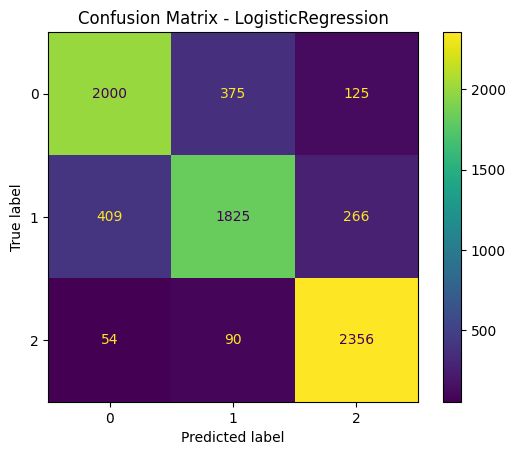

                   model  year      acc       f1  kappa
LogisticRegression | raw  2019 0.832000 0.828327  0.748
LogisticRegression | raw  2020 0.796667 0.789791  0.695
LogisticRegression | raw  2021 0.846000 0.845508  0.769
LogisticRegression | raw  2022 0.845333 0.843613  0.768
LogisticRegression | raw  2023 0.800667 0.800765  0.701


In [ ]:
# logistic regression
lr_raw, lr_raw_accuracy, lr_raw_f1, lr_raw_kappa, lr_raw_y_pred = evaluate_model('LogisticRegression', 
                        raw_models['LogisticRegression'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)
raw_lr_per_year = evaluate_per_year('LogisticRegression | raw', raw_models['LogisticRegression'], raw_x_test, raw_y_test, raw_test_df)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.92      0.73      0.81      2500
          potatoes       0.76      0.89      0.82      2500
     winter_barley       0.93      0.97      0.95      2500

          accuracy                           0.86      7500
         macro avg       0.87      0.86      0.86      7500
      weighted avg       0.87      0.86      0.86      7500



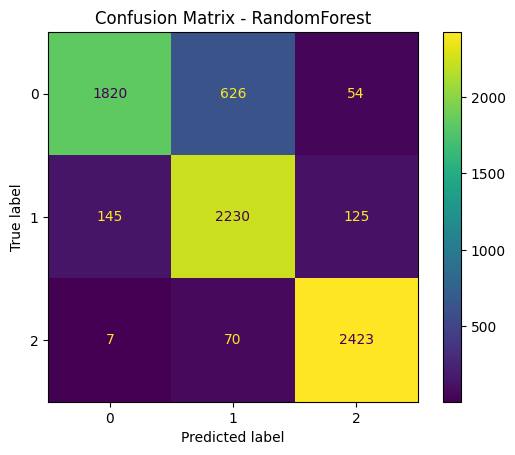

             model  year      acc       f1  kappa
RandomForest | raw  2019 0.869333 0.867645  0.804
RandomForest | raw  2020 0.861333 0.859668  0.792
RandomForest | raw  2021 0.890667 0.891478  0.836
RandomForest | raw  2022 0.873333 0.872891  0.810
RandomForest | raw  2023 0.820667 0.815953  0.731


In [108]:
# random forest
rf_raw, rf_raw_accuracy, rf_raw_f1, rf_raw_kappa, rf_raw_y_pred = evaluate_model('RandomForest', 
                        raw_models['RandomForest'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

raw_rf_per_year = evaluate_per_year('RandomForest | raw', raw_models['RandomForest'], raw_x_test, raw_y_test, raw_test_df)

# embeddings data

## pre processing

In [126]:
embeddings_df = pd.concat(embedding_data.values(), ignore_index=True)

print(f"Original embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}") 
print(f"Crops on embedding df: {embeddings_df['crop'].unique()}")
print(f"Years on embedding df: {embeddings_df['year'].unique()}")
print(f"Country on embedding df: {embeddings_df['country'].unique()}")

Original embeddings shape: (9000, 12)
Embedding length: 128
Crops on embedding df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on embedding df: [2018 2019 2020 2021 2022 2023]
Country on embedding df: ['fr']


In [127]:
# check Nan values
print(f"Nan values before for embeddings_df: {embeddings_df['embedding'].isnull().sum().sum()}")  

embeddings_df = embeddings_df[embeddings_df['embedding'].notnull()].fillna(0)

print(f"Nan values after for embeddings_df: {embeddings_df['embedding'].isnull().sum().sum()}")  

Nan values before for embeddings_df: 0
Nan values after for embeddings_df: 0


In [128]:
embeddings_df.head(2)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country,error
0,1.65,49.75,1005.0,532.0,EPSG:32631,"[2.3069363, -0.3938672, 0.7877344, 2.6445367, ...","[1.6736168980811237, 49.710431244293936]",maize_corn_popcorn,fr,2018,fr,0
1,1.05,49.05,512.0,16.0,EPSG:32631,"[4.9744644, 0.32442158, 1.027335, 2.865724, 2....","[1.0000396743907862, 49.05392391283792]",maize_corn_popcorn,fr,2018,fr,0


In [129]:
# drop whats no necessary
embeddings_df = embeddings_df.drop(columns=['tile_lon', 'tile_lat', 'pixel_row', 'pixel_col', 'crs', 'country_id', 'error'])
embeddings_df = embeddings_df[embeddings_df['country'] != 'pt'].reset_index(drop=True)
print(f"Processed embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}") 
print(f"Crops on embedding df: {embeddings_df['crop'].unique()}")
print(f"Years on embedding df: {embeddings_df['year'].unique()}")
print(f"Country on embedding df: {embeddings_df['country'].unique()}")

Processed embeddings shape: (9000, 5)
Embedding length: 128
Crops on embedding df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on embedding df: [2018 2019 2020 2021 2022 2023]
Country on embedding df: ['fr']


In [130]:
embeddings_df.head(2)

,embedding,long_lat,crop,year,country
0,"[2.3069363, -0.3938672, 0.7877344, 2.6445367, ...","[1.6736168980811237, 49.710431244293936]",maize_corn_popcorn,2018,fr
1,"[4.9744644, 0.32442158, 1.027335, 2.865724, 2....","[1.0000396743907862, 49.05392391283792]",maize_corn_popcorn,2018,fr


In [131]:
# expand the embeddings to features
emb_df = pd.DataFrame(embeddings_df['embedding'].tolist(), 
                             columns=[f'emb_{i}' for i in range(len(embeddings_df['embedding'].iloc[0]))])

emb_df['latitude'] = embeddings_df['long_lat'].apply(lambda x: x[1])
emb_df['longitude'] = embeddings_df['long_lat'].apply(lambda x: x[0])
emb_df['crop'] = embeddings_df['crop']
emb_df['country'] = embeddings_df['country']
emb_df['year'] = embeddings_df['year']

print(f"Final embeddings shape: {embeddings_df.shape}")

Final embeddings shape: (9000, 5)


In [132]:
emb_df.head(2)

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_123,emb_124,emb_125,emb_126,emb_127,latitude,longitude,crop,country,year
0,2.306936,-0.393867,0.787734,2.644537,1.519202,0.956535,-3.713605,-2.813337,-1.350402,5.964274,...,-4.613873,-6.358141,-1.012801,0.112533,0.787734,49.710431,1.673617,maize_corn_popcorn,fr,2018
1,4.974464,0.324422,1.027335,2.865724,2.595373,1.892459,-4.055270,-0.919194,0.811054,4.595973,...,-2.757583,-4.595973,0.756984,-0.162211,2.919794,49.053924,1.000040,maize_corn_popcorn,fr,2018


## split train test

In [97]:
emb_train_df = emb_df[emb_df['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
emb_test_df  = emb_df[emb_df['year'].isin(TEST_YEARS)].reset_index(drop=True)

In [98]:
drop_cols = ['latitude', 'longitude', 'crop', 'country', 'year']

emb_x_train = emb_train_df.drop(columns=drop_cols)
emb_y_train = emb_train_df['crop']

emb_x_test  = emb_test_df.drop(columns=drop_cols)
emb_y_test  = emb_test_df['crop']

print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (1500, 128)
Test shape for embeddings: (7500, 128)


In [117]:
# check Nan values
print(f"Nan values before for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values before for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

emb_x_train = emb_x_train.fillna(0)
emb_x_test  = emb_x_test.fillna(0)

print(f"Nan values after for emb_x_train: {emb_x_train.isnull().sum().sum()}")  
print(f"Nan values after for emb_x_text: {emb_x_test.isnull().sum().sum()}")   

Nan values before for emb_x_train: 0
Nan values before for emb_x_text: 0
Nan values after for emb_x_train: 0
Nan values after for emb_x_text: 0


In [100]:
print(f"Train shape for embeddigns: {emb_x_train.shape}")
print(f"Test shape for embeddings: {emb_x_test.shape}")

Train shape for embeddigns: (1500, 128)
Test shape for embeddings: (7500, 128)


## apply models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.87      0.87      0.87      2500
          potatoes       0.87      0.83      0.85      2500
     winter_barley       0.92      0.96      0.94      2500

          accuracy                           0.89      7500
         macro avg       0.89      0.89      0.89      7500
      weighted avg       0.89      0.89      0.89      7500



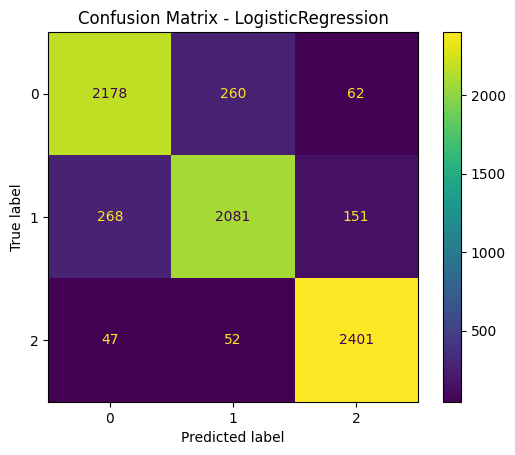

                   model  year      acc       f1  kappa
LogisticRegression | emb  2019 0.913333 0.912939  0.870
LogisticRegression | emb  2020 0.871333 0.870484  0.807
LogisticRegression | emb  2021 0.890000 0.889708  0.835
LogisticRegression | emb  2022 0.878000 0.877040  0.817
LogisticRegression | emb  2023 0.887333 0.885979  0.831


In [109]:
# logistic regression
lr_emb, lr_emb_accuracy, lr_emb_f1, lr_emb_kappa, lr_emb_y_pred = evaluate_model('LogisticRegression', 
                        emb_models['LogisticRegression'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)

emb_lr_per_year = evaluate_per_year('LogisticRegression | emb', emb_models['LogisticRegression'], emb_x_test, emb_y_test, emb_test_df)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.92      0.91      0.91      2500
          potatoes       0.89      0.87      0.88      2500
     winter_barley       0.94      0.97      0.95      2500

          accuracy                           0.92      7500
         macro avg       0.92      0.92      0.92      7500
      weighted avg       0.92      0.92      0.92      7500



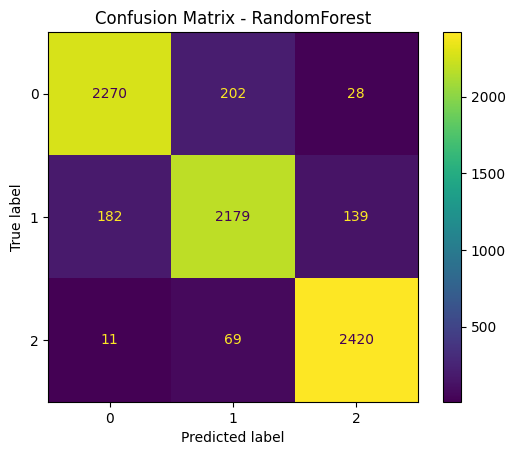

             model  year      acc       f1  kappa
RandomForest | emb  2019 0.933333 0.933258  0.900
RandomForest | emb  2020 0.897333 0.896543  0.846
RandomForest | emb  2021 0.906000 0.905493  0.859
RandomForest | emb  2022 0.926000 0.925887  0.889
RandomForest | emb  2023 0.916667 0.916179  0.875


In [110]:
# random forest
rf_emb, rf_emb_accuracy, rf_emb_f1, rf_emb_kappa, rf_emb_y_pred = evaluate_model('RandomForest', 
                        emb_models['RandomForest'], 
                        emb_x_train, emb_y_train, emb_x_test, emb_y_test)

emb_rf_per_year = evaluate_per_year('RandomForest | emb', emb_models['RandomForest'], emb_x_test, emb_y_test, emb_test_df)

# multi year train test

## degradation of accuracy and f1 per year

In [113]:
per_year_results = pd.concat([
    evaluate_per_year('LR | raw',  raw_models['LogisticRegression'], raw_x_test, raw_y_test, raw_test_df),
    evaluate_per_year('RF | raw',  raw_models['RandomForest'],       raw_x_test, raw_y_test, raw_test_df),
    evaluate_per_year('LR | emb',  emb_models['LogisticRegression'], emb_x_test, emb_y_test, emb_test_df),
    evaluate_per_year('RF | emb',  emb_models['RandomForest'],       emb_x_test, emb_y_test, emb_test_df),
], ignore_index=True)

   model  year      acc       f1  kappa
LR | raw  2019 0.832000 0.828327  0.748
LR | raw  2020 0.796667 0.789791  0.695
LR | raw  2021 0.846000 0.845508  0.769
LR | raw  2022 0.845333 0.843613  0.768
LR | raw  2023 0.800667 0.800765  0.701
   model  year      acc       f1  kappa
RF | raw  2019 0.869333 0.867645  0.804
RF | raw  2020 0.861333 0.859668  0.792
RF | raw  2021 0.890667 0.891478  0.836
RF | raw  2022 0.873333 0.872891  0.810
RF | raw  2023 0.820667 0.815953  0.731
   model  year      acc       f1  kappa
LR | emb  2019 0.913333 0.912939  0.870
LR | emb  2020 0.871333 0.870484  0.807
LR | emb  2021 0.890000 0.889708  0.835
LR | emb  2022 0.878000 0.877040  0.817
LR | emb  2023 0.887333 0.885979  0.831
   model  year      acc       f1  kappa
RF | emb  2019 0.933333 0.933258  0.900
RF | emb  2020 0.897333 0.896543  0.846
RF | emb  2021 0.906000 0.905493  0.859
RF | emb  2022 0.926000 0.925887  0.889
RF | emb  2023 0.916667 0.916179  0.875


## embeddings drift

In [114]:
def reducer(data, n_components=2, method='umap'):
    if method == "umap":
        reducer = umap.UMAP(n_components=n_components, 
                            n_neighbors=30, 
                            min_dist=0.1, 
                            metric='cosine', 
                            random_state=42)
    elif method == "pca":
        reducer = PCA(n_components=n_components)
    elif method == "tsne":
        reducer = TSNE(n_components=n_components, 
                       perplexity=50, 
                       learning_rate='auto', 
                       init='pca', 
                       metric='cosine', 
                       random_state=42)
    
    data_2d = reducer.fit_transform(data)
    return data_2d

In [138]:
def embedding_drift(embeddings_df):
    # drop rows where embedding is None or contains NaN
    mask        = embeddings_df['embedding'].apply(lambda x: x is not None and not np.any(np.isnan(x)))
    clean_df    = embeddings_df[mask].reset_index(drop=True)
    dropped     = len(embeddings_df) - len(clean_df)
    if dropped > 0:
        print(f"Dropped {dropped} rows with NaN embeddings")

    emb_matrix  = np.stack(clean_df['embedding'].values)
    years       = clean_df['year'].values
    crops       = clean_df['crop'].values

    proj = reducer(emb_matrix, n_components=2, method='umap')

    drift_df = pd.DataFrame({
        'pc1':  proj[:, 0],
        'pc2':  proj[:, 1],
        'year': years,
        'crop': crops,
    })

    centroids      = drift_df.groupby('year')[['pc1', 'pc2']].mean()
    crop_centroids = drift_df.groupby(['crop', 'year'])[['pc1', 'pc2']].mean()
    
    print("Global centroids per year:")
    print(centroids)
    print("\nPer-crop centroids per year:")
    print(crop_centroids)

    return drift_df, centroids, crop_centroids

In [139]:
drift_df, centroids, crop_centroids = embedding_drift(embeddings_df)

Dropped 3 rows with NaN embeddings


/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Global centroids per year:
           pc1       pc2
year                    
2018  6.894807  6.203917
2019  6.827552  6.164237
2020  7.272582  6.950362
2021  6.420468  5.739292
2022  7.264812  6.270432
2023  7.318245  5.979220

Per-crop centroids per year:
                               pc1       pc2
crop               year                     
maize_corn_popcorn 2018   3.757370  8.432513
                   2019   3.161312  7.968724
                   2020   3.470163  8.485812
                   2021   1.233296  7.122627
                   2022   3.427409  8.088573
                   2023   3.117378  7.616076
potatoes           2018   4.463984  3.247628
                   2019   4.116298  3.612692
                   2020   6.031624  4.865190
                   2021   4.574004  3.620902
                   2022   4.888014  3.310854
                   2023   4.354260  3.005509
winter_barley      2018  12.463067  6.931609
                   2019  13.205047  6.911295
                   2020

**Global centroids** — the overall cloud moves very little across years. The range in pc1 is roughly 6.4–7.3, in pc2 roughly 5.7–7.0. That's small relative to the scale of the UMAP space, confirming what the silhouette already told you: the embedding space has almost no year structure globally.

**Per-crop centroids** — this is the more interesting part. Each crop occupies a clearly distinct region of the UMAP space and stays there across years:

- maize: pc1 ≈ 1–4, pc2 ≈ 7–8
- potatoes: pc1 ≈ 4–6, pc2 ≈ 3–5
- winter barley: pc1 ≈ 12–14, pc2 ≈ 6–7

The three crops are well separated (no overlap in their centroid ranges), and within each crop the year-to-year centroid movement is small relative to the between-crop distances. For example, maize drifts ~2 units in pc1 across years, while maize and potatoes are ~8 units apart — so the drift is small relative to the discrimination signal.

**The one exception worth noting** is 2021, which consistently sits slightly off from the other years across all three crops (maize pc1=1.2 vs ~3–4 for other years, potatoes and barley also slightly shifted). This suggests 2021 had some year-specific signal — possibly a weather anomaly — but it didn't break crop separability.

**Summary**: the crop regions are stable across time, drift is small relative to inter-crop distances, and the classifier trained on 2018 is navigating essentially the same geometry in 2023. This is strong geometric evidence for temporal generalization.

# analysis

## basic metrics

In [42]:
print(f"For LogisticRegression with raw data, \n accuracy = {lr_raw_accuracy:.2f} \n f1_macro = {lr_raw_f1:.2f} \n kappa = {lr_raw_kappa:.2f}")
print(f"For RandomForest with raw data, \n accuracy = {rf_raw_accuracy:.2f} \n f1_macro = {rf_raw_f1:.2f} \n kappa = {rf_raw_kappa:.2f}")
print(f"For LogisticRegression with embedding data, \n accuracy = {lr_emb_accuracy:.2f} \n f1_macro = {lr_emb_f1:.2f} \n kappa = {lr_emb_kappa:.2f}")
print(f"For RandomForest with embedding data, \n accuracy = {rf_emb_accuracy:.2f} \n f1_macro = {rf_emb_f1:.2f} \n kappa = {rf_emb_kappa:.2f}")

For LogisticRegression with raw data, 
 accuracy = 0.82 
 f1_macro = 0.82 
 kappa = 0.74
For RandomForest with raw data, 
 accuracy = 0.86 
 f1_macro = 0.86 
 kappa = 0.79
For LogisticRegression with embedding data, 
 accuracy = 0.89 
 f1_macro = 0.89 
 kappa = 0.83
For RandomForest with embedding data, 
 accuracy = 0.92 
 f1_macro = 0.92 
 kappa = 0.87


## spatial visual analysis

In [44]:
def plot_embedding_space(data, labels, method='umap'):
    data_2d = reducer(data.values, method=method)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # color by crop
    crops = labels['crop'].unique()
    
    ax = axes[0]
    for crop in crops:
        mask = labels['crop'] == crop
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=crop, alpha=0.5, s=10)
    ax.set_title('Colored by Crop')
    ax.legend()
    
    # color by country
    years = labels['year'].unique()
    
    ax = axes[1]
    for i, year in enumerate(years):
        mask = labels['year'] == year
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], label=year, alpha=0.5, s=10)
    ax.set_title('Colored by Year')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return data_2d

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


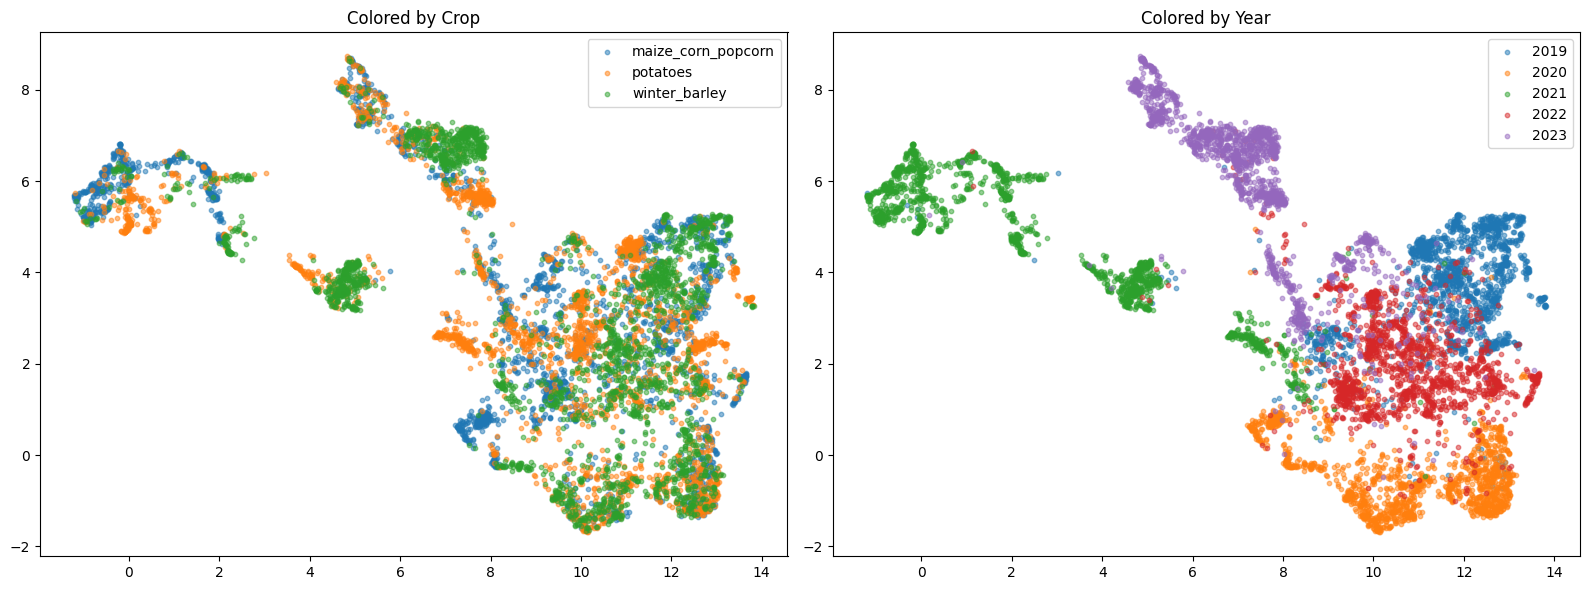

In [45]:
# raw test
emb_2d = plot_embedding_space(raw_x_test, 
                              raw_test_df, 
                              method='umap')

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


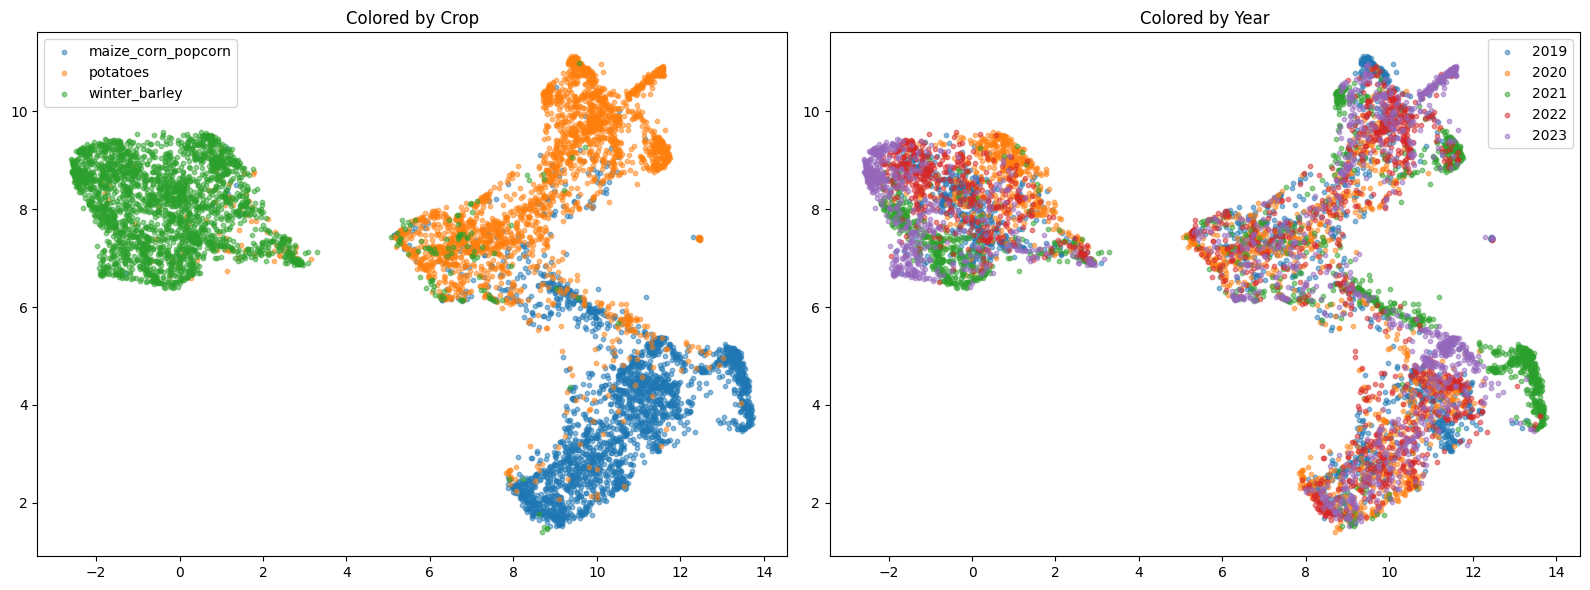

In [48]:
# embeddings test
emb_2d = plot_embedding_space(emb_x_test, 
                              emb_test_df,
                              method='umap')

## correlation matrix

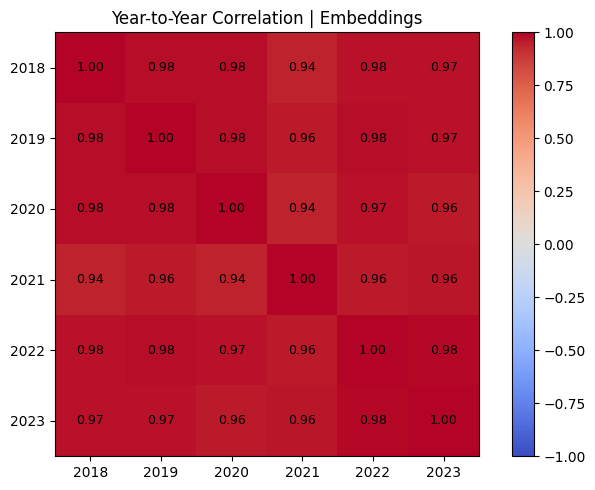

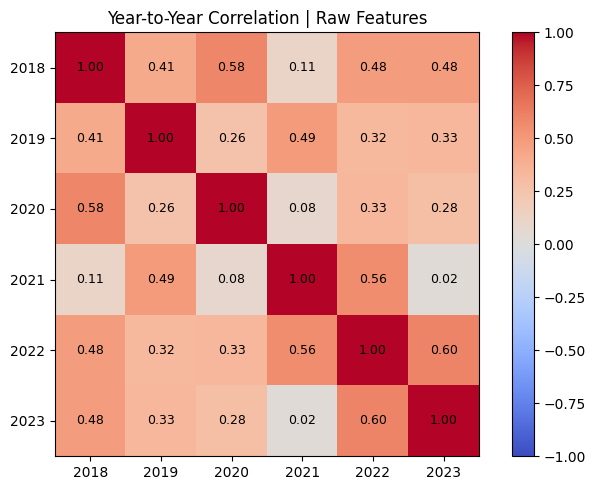

In [140]:
def plot_year_correlation_matrix(df, feature_cols, title):
    years      = sorted(df['year'].unique())
    year_means = pd.DataFrame({
        year: df[df['year'] == year][feature_cols].mean()
        for year in years
    })

    corr = year_means.corr()

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(years)))
    ax.set_yticks(range(len(years)))
    ax.set_xticklabels(years)
    ax.set_yticklabels(years)
    for i in range(len(years)):
        for j in range(len(years)):
            ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# for embeddings
emb_feature_cols = [c for c in emb_df.columns if c.startswith('emb_')]
plot_year_correlation_matrix(emb_df, emb_feature_cols, 'Year-to-Year Correlation | Embeddings')

# for raw
raw_feature_cols = [c for c in raw_df.columns if c not in ['latitude', 'longitude', 'country', 'crop', 'year']]
plot_year_correlation_matrix(raw_df, raw_feature_cols, 'Year-to-Year Correlation | Raw Features')

## comparing embeddings metrics

**COSINE SIMILARITY** Measures the angle between two vectors. Direction matters, magnitude does not. Ignores scale differences between countries, captures pattern/direction. 
- oposite meaning -1
- unrealated 0
- super related 1

**EUCLIDEAN DISTANCE** Measures straight-line distance between two points. Both direction AND magnitude matter so scaler is important.
- identical/very close 0
- very far/super different ∞

**SILHOUETE** Measures how well a point fits its own cluster vs the nearest other cluster. A per-point score, averaged. Use to evaluate overall cluster quality. Works with any distance metric, which is why you should pass `metric='cosine'` for embeddings.
- in the wrong cluster -1
- on boudary 0
- perfectly separated 1

In [143]:
def cosine_similarity_metric(data, labels, evaluate='crop'):
    metric           = cosine_similarity(data.values)
    evaluate_labels  = labels[evaluate].reset_index(drop=True).values
    records          = []
    for evaluation in np.unique(evaluate_labels):
        mask  = evaluate_labels == evaluation
        intra = metric[np.ix_(mask, mask)]
        np.fill_diagonal(intra, np.nan)
        inter = metric[np.ix_(mask, ~mask)]
        records.append({'label': evaluation, 'same': np.nanmean(intra), 'different': inter.mean()})
    return metric, records

def euclidean_distances_metric(data, labels, evaluate='crop'):
    scaler           = StandardScaler()
    metric           = euclidean_distances(scaler.fit_transform(data.values))
    evaluate_labels  = labels[evaluate].reset_index(drop=True).values
    records          = []
    for evaluation in np.unique(evaluate_labels):
        mask  = evaluate_labels == evaluation
        intra = metric[np.ix_(mask, mask)]
        np.fill_diagonal(intra, np.nan)
        inter = metric[np.ix_(mask, ~mask)]
        records.append({'label': evaluation, 'same': np.nanmean(intra), 'different': inter.mean()})
    return metric, records

def silhouete_metric(data, labels, evaluate='crop'):
    evaluate_labels = labels[evaluate].reset_index(drop=True).values
    overall         = silhouette_score(data, evaluate_labels, metric='cosine')
    sample_scores   = silhouette_samples(data.values, evaluate_labels, metric='cosine')
    records         = [{'label': 'overall', 'silhouette': overall}]
    for label in np.unique(evaluate_labels):
        mask = evaluate_labels == label
        records.append({'label': label, 'silhouette': sample_scores[mask].mean()})
    return overall, records

def plot_metrics(data, labels):
    crop_labels    = labels['crop'].reset_index(drop=True).values
    country_labels = labels['country'].reset_index(drop=True).values
    
    sort_idx = np.lexsort((country_labels, crop_labels))
    sorted_data    = data[np.ix_(sort_idx, sort_idx)]
    sorted_crops   = crop_labels[sort_idx]
    sorted_countries = country_labels[sort_idx]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(sorted_data, aspect='auto')
    plt.colorbar(im, ax=ax)
    
    tick_positions = []
    tick_labels    = []
    i = 0
    while i < len(sorted_crops):
        j = i
        while j < len(sorted_crops) and sorted_crops[j] == sorted_crops[i] and sorted_countries[j] == sorted_countries[i]:
            j += 1
        center = (i + j - 1) / 2
        tick_positions.append(center)
        tick_labels.append(f"{sorted_crops[i]}\n({sorted_countries[i]})")
        i = j
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=8)
    
    plt.tight_layout()
    plt.show()


In [147]:
datasets = {
    'Embeddings':   (emb_x_test, emb_test_df),
    'Raw Features': (raw_x_test, raw_test_df),
}

metrics = {
    'Cosine Similarity':  cosine_similarity_metric,
    'Euclidean Distance': euclidean_distances_metric,
}

rows = []

for data_name, (data, labels) in datasets.items():
    for metric_name, metric_fn in metrics.items():
        for evaluate in ['crop', 'year']:
            _, records = metric_fn(data, labels, evaluate=evaluate)
            for r in records:
                rows.append({
                    'data':     data_name,
                    'metric':   metric_name,
                    'evaluate': evaluate,
                    'label':    str(r['label']),
                    'same':     r['same'],
                    'different': r['different'],
                })

    for evaluate in ['crop', 'year']:
        _, records = silhouete_metric(data, labels, evaluate=evaluate)
        for r in records:
            rows.append({
                'data':       data_name,
                'metric':     'Silhouette',
                'evaluate':   evaluate,
                'label':      str(r['label']),
                'same':       r['silhouette'],
                'different':  np.nan,
            })

embeddings_metrics = pd.DataFrame(rows)
embeddings_metrics

,data,metric,evaluate,label,same,different
0,Embeddings,Cosine Similarity,crop,maize_corn_popcorn,0.669615,0.506052
1,Embeddings,Cosine Similarity,crop,potatoes,0.597372,0.492427
2,Embeddings,Cosine Similarity,crop,winter_barley,0.731383,0.478533
3,Embeddings,Cosine Similarity,year,2019,0.557613,0.547308
4,Embeddings,Cosine Similarity,year,2020,0.580258,0.549434
5,Embeddings,Cosine Similarity,year,2021,0.566875,0.539942
6,Embeddings,Cosine Similarity,year,2022,0.574553,0.554266
7,Embeddings,Cosine Similarity,year,2023,0.546481,0.541685
8,Embeddings,Euclidean Distance,crop,maize_corn_popcorn,13.750189,16.541361
9,Embeddings,Euclidean Distance,crop,potatoes,14.564941,16.680252


# Embedding Space Analysis — Temporal Generalization

## Embeddings — By Crop

Strong separation between same and different class in both cosine and euclidean space.
Winter barley is the most separable (cosine 0.731 vs 0.479, silhouette 0.456), potatoes the hardest (0.597 vs 0.492, silhouette 0.125).
The embedding space genuinely organizes by crop identity.

## Embeddings — By Year

Same-year vs different-year distances are nearly identical across all metrics. Silhouette ≈ 0.000.
**This is the key result: the embedding space has almost no year structure.**
Points from 2019 and 2023 live in the same neighborhood.
For temporal generalization this is exactly what you want — the model trained on 2018 sees a test year that looks geometrically the same.

## Raw Features — By Crop

Cosine similarity between same and different class is essentially identical (e.g. 0.920 vs 0.922).
Silhouette overall 0.017, with maize even negative.
**Raw features do not separate crops in feature space at all** — the classifier is working much harder with much less signal.

## Raw Features — By Year

Silhouette by year is 0.085, which is actually *higher* than embeddings (≈ 0.000).
This means **raw features cluster more by year than embeddings do** — the feature space has year-specific structure baked in.
When you train on 2018 and test on 2022, the classifier is crossing a real geometric gap.

---

## Synthesis

|                | Crop separation | Year separation |
|----------------|-----------------|-----------------|
| Embeddings     | ✓ strong        | ✗ nearly none   |
| Raw features   | ✗ very weak     | ~ moderate      |

Embeddings encode *what* the crop is, independently of *when* it was observed.
Raw features encode a mix of both, which explains why they classify reasonably well within-year but will degrade faster across years.
Your per-year degradation curve should show a flatter slope for embeddings than for raw features — these geometry results predict exactly that.